# Proyecto: Análisis y Predicción del Impacto del COVID-19
## Autor: Diego Castro

In [64]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB

In [29]:
# Lectura del dataset
country = pd.read_csv("country_wise_latest.csv")

In [36]:
country.shape

(187, 17)

In [8]:
country.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


## EDA

In [16]:
country.info()

<class 'pandas.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    str    
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    str    
dtype

In [17]:
country.describe()

/opt/miniconda3/lib/python3.13/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase
count,1.870000e+02,187.000000,1.870000e+02,1.870000e+02,187.000000,187.000000,187.000000,187.000000,187.000000,187.00,1.870000e+02,187.000000,187.000000
mean,8.813094e+04,3497.518717,5.063148e+04,3.400194e+04,1222.957219,28.957219,933.812834,3.019519,64.820535,inf,7.868248e+04,9448.459893,13.606203
std,3.833187e+05,14100.002482,1.901882e+05,2.133262e+05,5710.374790,120.037173,4197.719635,3.454302,26.287694,NaN,3.382737e+05,47491.127684,24.509838
min,1.000000e+01,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,1.000000e+01,-47.000000,-3.840000
25%,1.114000e+03,18.500000,6.265000e+02,1.415000e+02,4.000000,0.000000,0.000000,0.945000,48.770000,1.45,1.051500e+03,49.000000,2.775000
50%,5.059000e+03,108.000000,2.815000e+03,1.600000e+03,49.000000,1.000000,22.000000,2.150000,71.320000,3.62,5.020000e+03,432.000000,6.890000
75%,4.046050e+04,734.000000,2.260600e+04,9.149000e+03,419.500000,6.000000,221.000000,3.875000,86.885000,6.44,3.708050e+04,3172.000000,16.855000
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06,56336.000000,1076.000000,33728.000000,28.560000,100.000000,inf,3.834677e+06,455582.000000,226.320000


In [20]:
# verificar si hay valores nulos
country.isnull().sum()

Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64

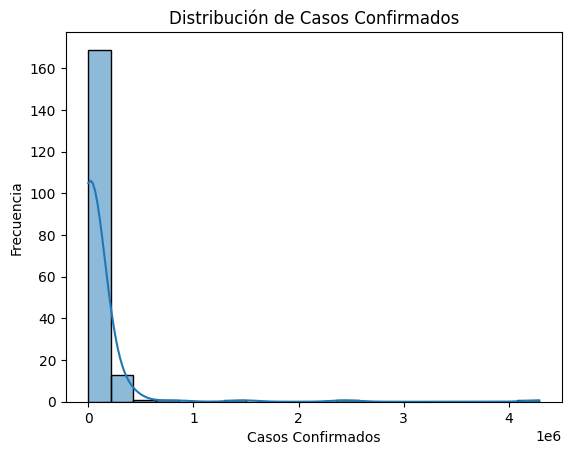

In [26]:
sns.histplot(data=country, x="Confirmed", bins=20, kde=True)
plt.title("Distribución de Casos Confirmados")
plt.xlabel("Casos Confirmados")
plt.ylabel("Frecuencia")
plt.show()

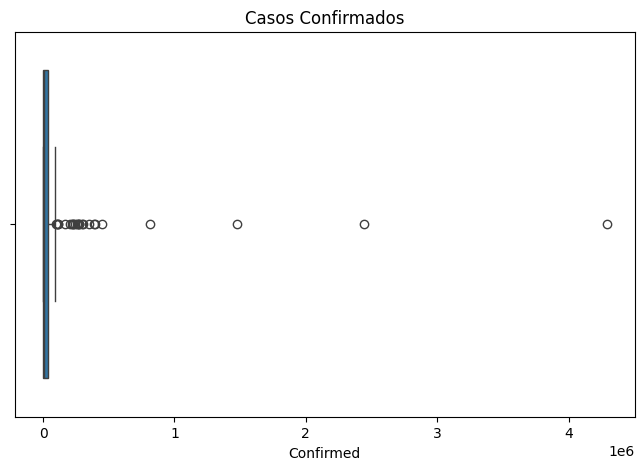

In [41]:
plt.figure(figsize=(8,5))
sns.boxplot(x=country["Confirmed"])
plt.title("Casos Confirmados")
plt.show()

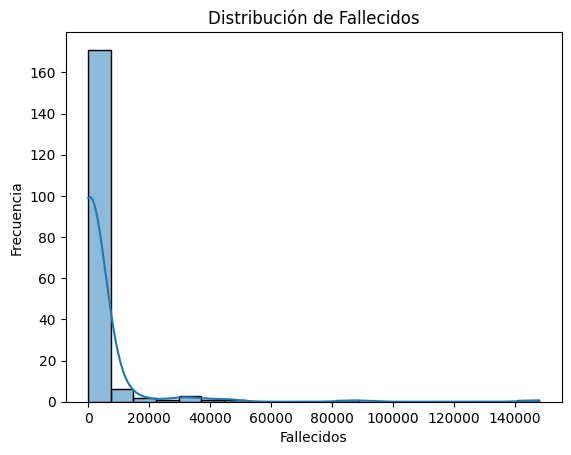

In [42]:
sns.histplot(data=country, x="Deaths", bins=20, kde=True)
plt.title("Distribución de Fallecidos")
plt.xlabel("Fallecidos")
plt.ylabel("Frecuencia")
plt.show()

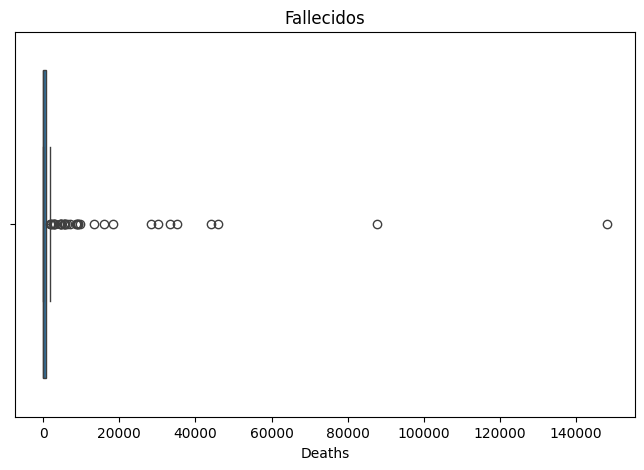

In [43]:
plt.figure(figsize=(8,5))
sns.boxplot(x=country["Deaths"])
plt.title("Fallecidos")
plt.show()

In [33]:
country["Nivel de Riesgo"] = pd.cut(country["Deaths"],
    bins=[0,1000,10000,1000000],
    labels=["Bajo","Medio","Alto"]
)
country["Nivel de Riesgo"].value_counts()

Nivel de Riesgo
Bajo     126
Medio     33
Alto      11
Name: count, dtype: int64

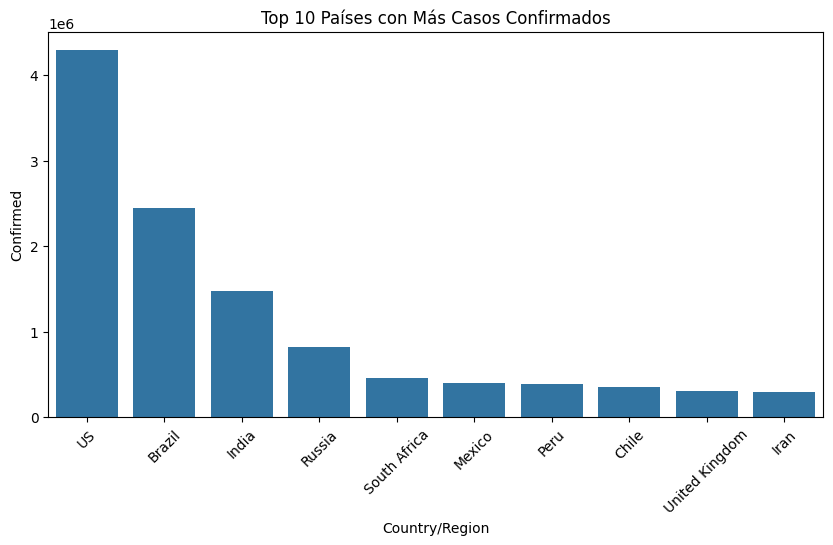

In [45]:
top_confirmed = country.nlargest(10, "Confirmed")
plt.figure(figsize=(10,5))
sns.barplot(data=top_confirmed,x="Country/Region",y="Confirmed")
plt.xticks(rotation=45)
plt.title("Top 10 Países con Más Casos Confirmados")
plt.show()

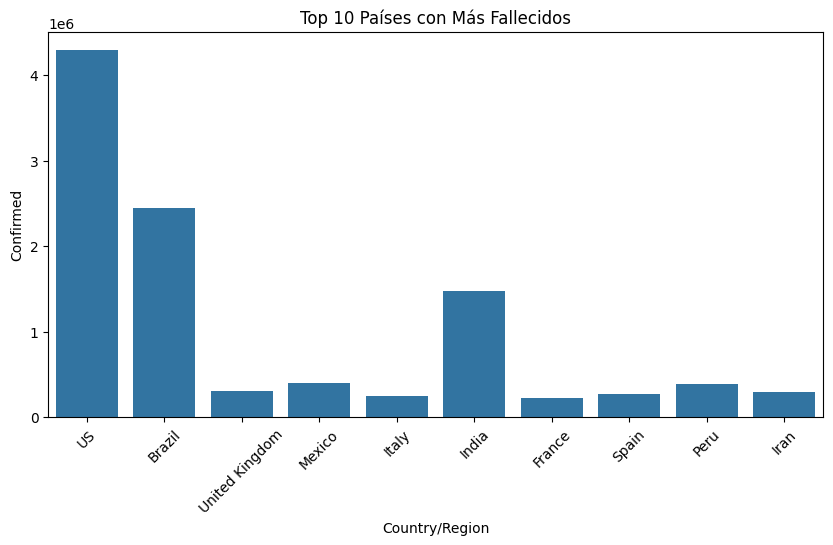

In [46]:
top_deaths = country.nlargest(10, "Deaths")
plt.figure(figsize=(10,5))
sns.barplot(data=top_deaths,x="Country/Region",y="Confirmed")
plt.xticks(rotation=45)
plt.title("Top 10 Países con Más Fallecidos")
plt.show()

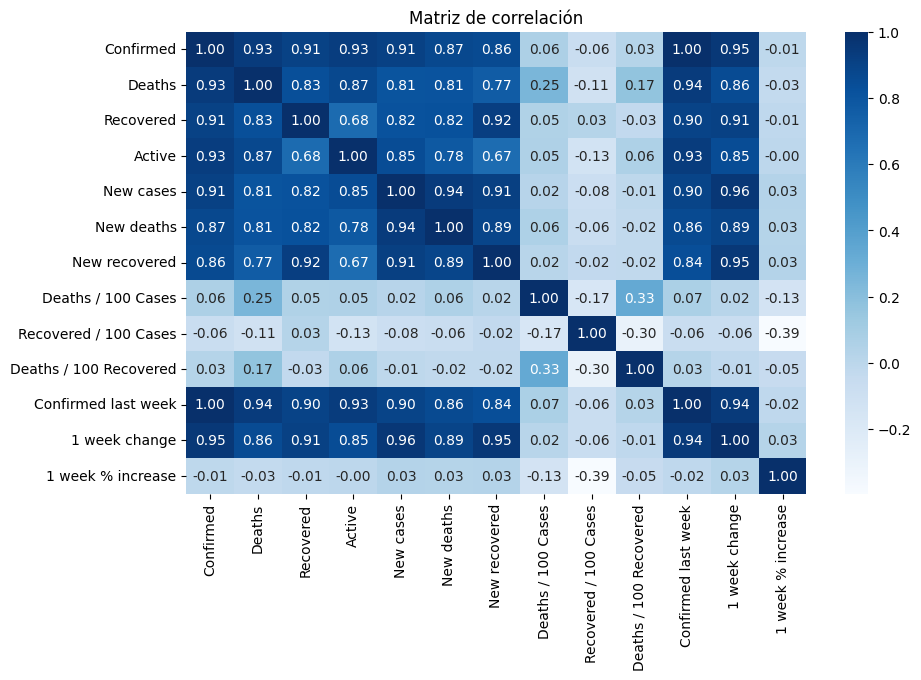

In [47]:
plt.figure(figsize=(10, 6))
sns.heatmap(country.select_dtypes(include=np.number).corr(),annot=True,cmap="Blues",fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

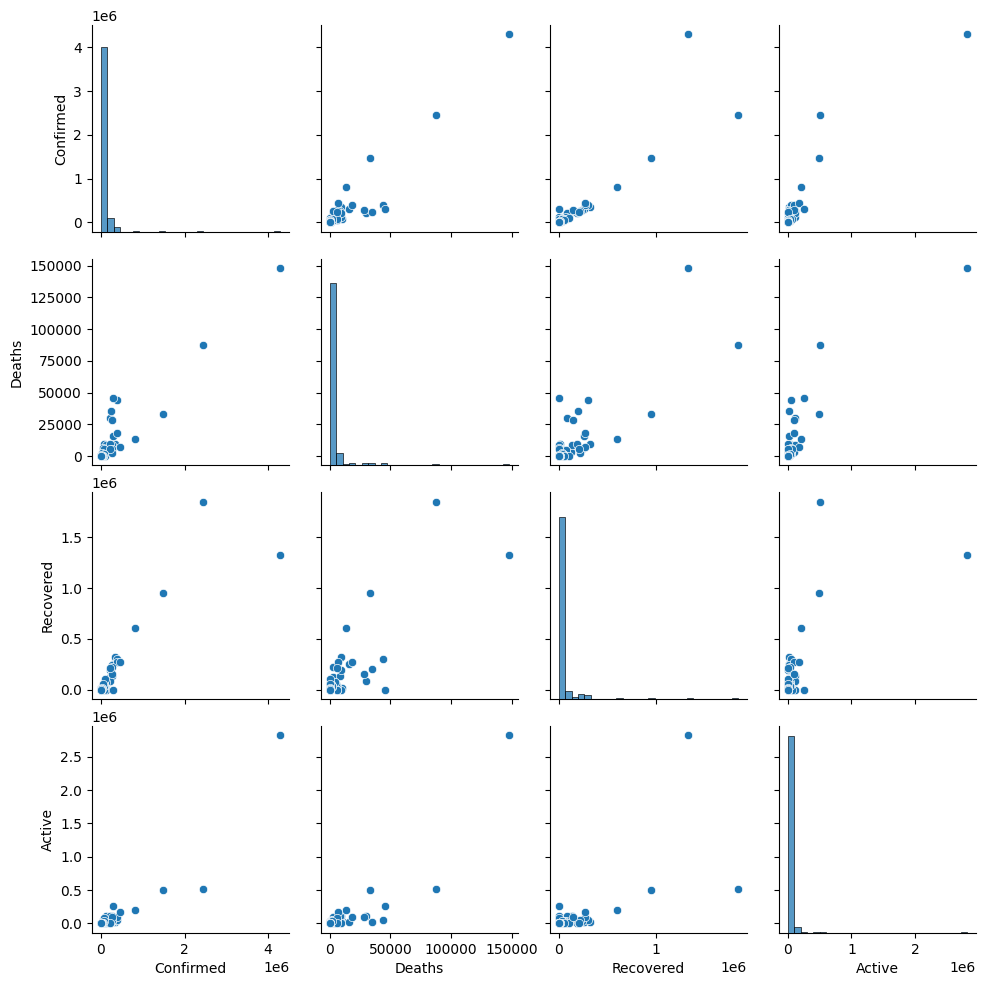

In [48]:
variables = ["Confirmed","Deaths","Recovered","Active"]
sns.pairplot(country[variables])
plt.show()

## Feature Engineering

In [ ]:
# Tasa de mortalidad 
country["Mortality_Rate"] = (country["Deaths"] / country["Confirmed"]) * 100


In [53]:
# Tasa de recuperación
country["Recovery_Rate"] = (country["Recovered"] / country["Confirmed"]) * 100


In [54]:
# Tasa de activos (en el 2020)
country["Active_Rate"] = (country["Active"] / country["Confirmed"]) * 100


In [ ]:
# Valores de las tasas
country[["Country/Region","Mortality_Rate","Recovery_Rate","Active_Rate"]].head(10)

,Country/Region,Mortality_Rate,Recovery_Rate,Active_Rate
0,Afghanistan,3.499435,69.486805,27.013761
1,Albania,2.950820,56.250000,40.799180
2,Algeria,4.157581,67.339935,28.502485
3,Andorra,5.733186,88.533627,5.733186
4,Angola,4.315789,25.473684,70.210526
5,Antigua and Barbuda,3.488372,75.581395,20.930233
6,Argentina,1.827185,43.350098,54.822717
7,Armenia,1.901578,71.315860,26.782562
8,Australia,1.091289,60.844279,38.064432
9,Austria,3.468236,88.753770,7.777994


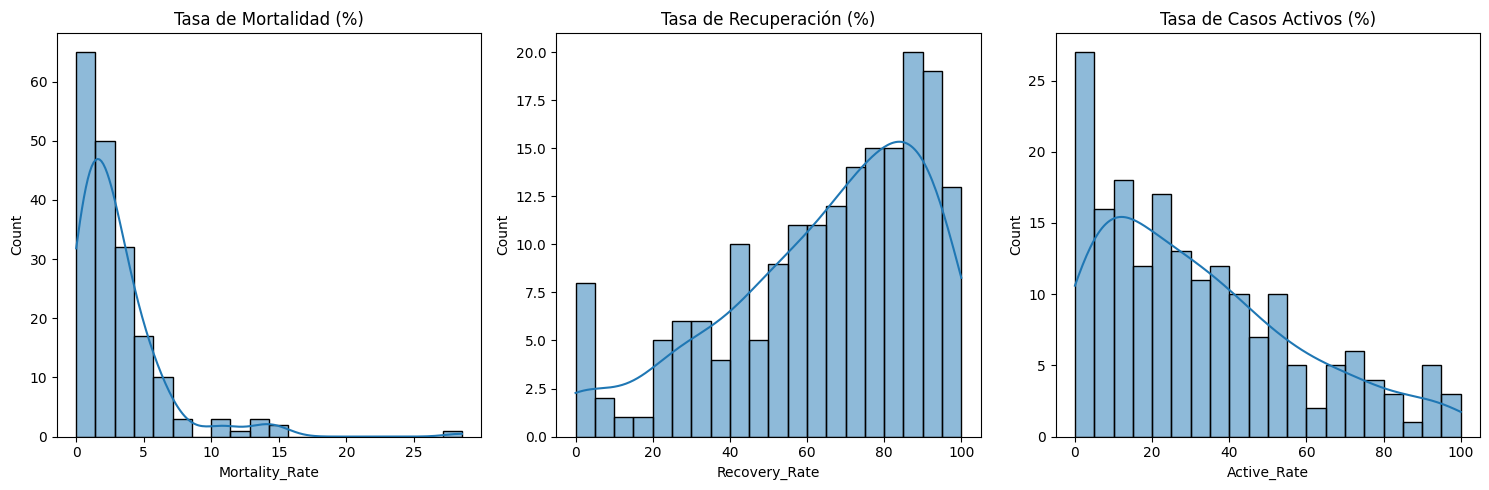

In [60]:
# Graficación de las tasas
fig, axes = plt.subplots(1, 3, figsize=(15,5))
sns.histplot(
    data=country,
    x="Mortality_Rate",
    bins=20,
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Tasa de Mortalidad (%)")
sns.histplot(
    data=country,
    x="Recovery_Rate",
    bins=20,
    kde=True,
    ax=axes[1]
)
axes[1].set_title("Tasa de Recuperación (%)")

sns.histplot(
    data=country,
    x="Active_Rate",
    bins=20,
    kde=True,
    ax=axes[2]
)
axes[2].set_title("Tasa de Casos Activos (%)")
plt.tight_layout()
plt.show()

In [57]:
country["Risk_Level"] = pd.cut(country["Deaths"],
    bins=[0, 1000, 10000, country["Deaths"].max()],
    labels=["Bajo", "Medio", "Alto"])
country["Risk_Level"].value_counts()

Risk_Level
Bajo     126
Medio     33
Alto      11
Name: count, dtype: int64

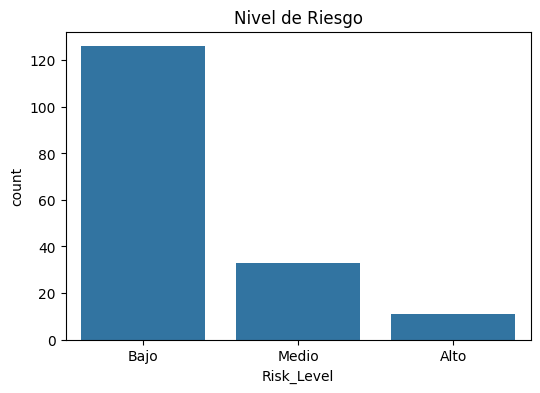

In [61]:
plt.figure(figsize=(6,4))
sns.countplot(data=country,x="Risk_Level")
plt.title("Nivel de Riesgo")
plt.show()

In [137]:
riesgo_mapa = {
    "Bajo": 0,
    "Medio": 1,
    "Alto": 2
}
country["Risk_Level"] = country["Risk_Level"].map(riesgo_mapa)
country[["Country/Region", "Deaths", "Risk_Level", "Risk_Label"]].head(10)

,Country/Region,Deaths,Risk_Level,Risk_Label
0,Afghanistan,1269,2,NaN
1,Albania,144,1,NaN
2,Algeria,1163,2,NaN
3,Andorra,52,1,NaN
4,Angola,41,0,NaN
5,Antigua and Barbuda,3,0,NaN
6,Argentina,3059,2,NaN
7,Armenia,711,2,NaN
8,Australia,167,1,NaN
9,Austria,713,2,NaN


In [143]:
y = country["Risk_Level"]
X = country[[
        "New cases",
        "New recovered",
        "Confirmed last week",
        "1 week change",
        "1 week % increase",
        "Recovered / 100 Cases"
    ]]

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [148]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42,stratify=y)

## PCA

In [125]:
pca_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA())
])
pca_pipeline.fit(X_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('pca', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full

In [162]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
varianza_acumulada = np.cumsum(
    pca.explained_variance_ratio_
)
varianza_acumulada

array([0.6267204 , 0.85840663, 0.95994387, 0.98617745, 0.99804719,
       1.        ])

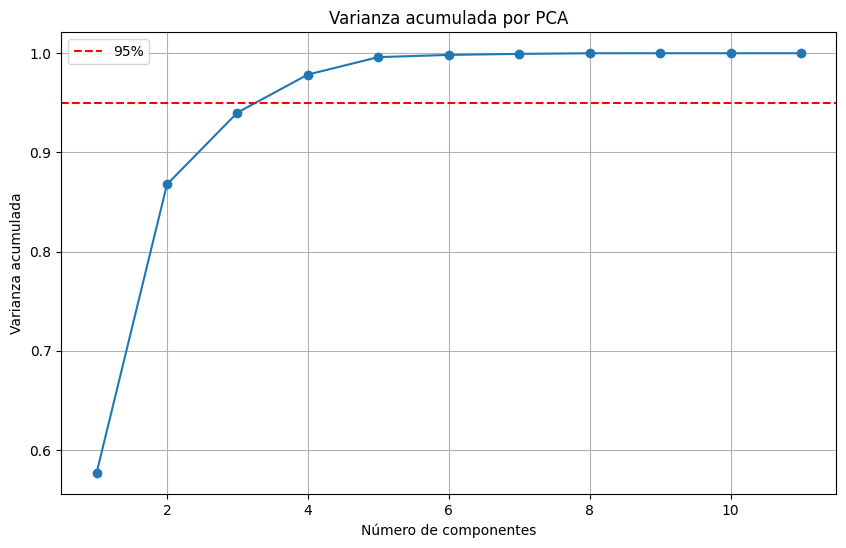

In [127]:
plt.figure(figsize=(10,6))
plt.plot(range(1, len(varianza_acumulada)+1), varianza_acumulada, marker="o")
plt.axhline(
    y=0.95,
    color="red",
    linestyle="--",
    label="95%"
)
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.title("Varianza acumulada por PCA")
plt.legend()
plt.grid()
plt.show()

In [128]:
n_components = np.argmax(varianza_acumulada >= 0.95) + 1
print(f"Componentes necesarios para explicar el 95% de la varianza: {n_components}")

Componentes necesarios para explicar el 95% de la varianza: 4


## Regresión Logística

In [153]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
y_pred_lr = lr.predict(X_test)

In [154]:
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, average="weighted")
rec_lr = recall_score(y_test, y_pred_lr, average="weighted")
f1_lr = f1_score(y_test, y_pred_lr, average="weighted")
print("Accuracy: ", acc_lr)
print("Presicion: ", prec_lr)
print("Recall: ", rec_lr)
print("F1-score:", f1_lr)

Accuracy:  0.5263157894736842
Presicion:  0.5581140350877194
Recall:  0.5263157894736842
F1-score: 0.5362976406533576


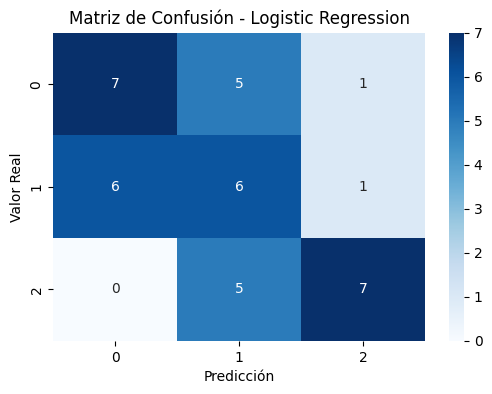

In [155]:
cm_lr = confusion_matrix(y_test,y_pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(cm_lr,annot=True,fmt="d",cmap="Blues")
plt.title("Matriz de Confusión - Logistic Regression")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

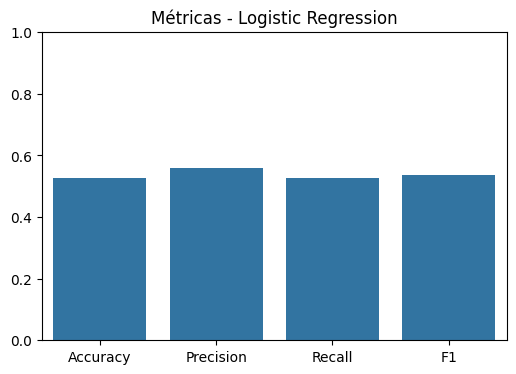

In [156]:
metricas_lr = [acc_lr, prec_lr, rec_lr, f1_lr]
plt.figure(figsize=(6,4))
sns.barplot(x=["Accuracy", "Precision", "Recall", "F1"],y=metricas_lr)
plt.ylim(0,1)
plt.title("Métricas - Logistic Regression")
plt.show()

## Random Forest

In [157]:
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [158]:
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average="weighted")
rec_rf = recall_score(y_test, y_pred_rf, average="weighted")
f1_rf = f1_score(y_test, y_pred_rf, average="weighted")
print("Accuracy: ", acc_rf)
print("Presicion: ", prec_rf)
print("Recall: ", rec_rf)
print("F1-score:", f1_rf)

Accuracy:  0.868421052631579
Presicion:  0.8680836707152497
Recall:  0.868421052631579
F1-score: 0.8673684210526316


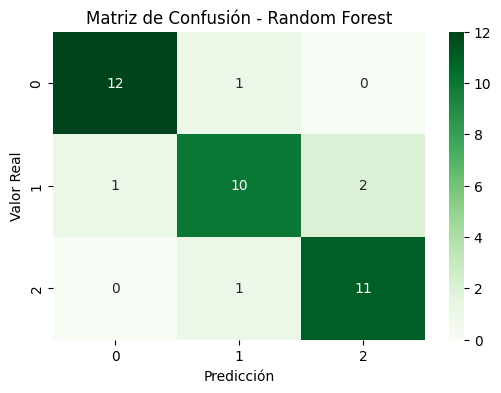

In [159]:
cm_rf = confusion_matrix(y_test,y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf,annot=True,fmt="d",cmap="Greens")
plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

## Comparación Regresión Linear y Random Forest

In [160]:
resultados = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [acc_lr, acc_rf],
    'Precision': [prec_lr, prec_rf],
    'Recall': [rec_lr, rec_rf],
    'F1': [f1_lr, f1_rf]
})
resultados

,Modelo,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.526316,0.558114,0.526316,0.536298
1,Random Forest,0.868421,0.868084,0.868421,0.867368


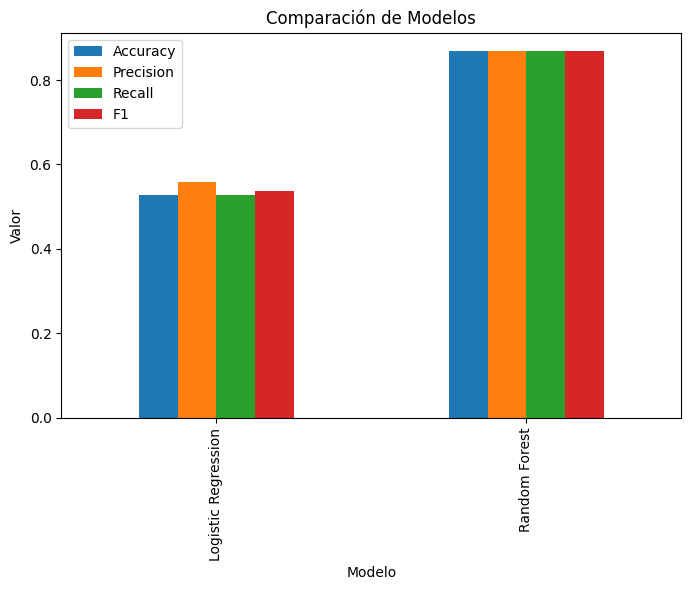

In [ ]:
resultados.set_index("Modelo").plot(kind="bar",figsize=(8,5))
plt.title("Comparación de Modelos")
plt.ylabel("Valor")
plt.show()